In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

DATA_DIR = Path("data")

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test_x.csv")

TARGET = "bilissel_performans_skoru"

X = train.drop(columns=[TARGET])
y = train[TARGET]

print("Train:", train.shape)
print("Test:", test.shape)

display(train.head())
display(test.head())

Train: (56000, 24)
Test: (24000, 23)


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi
0,1,42,Erkek,Saglik Personeli,29.728724,Ingiltere,21.691917,23.990157,21,5,...,0,6.349196,9.419561,Gece insani,Depresyon,82,21.627129,1.716161,Ilkbahar-Yaz,Hafta sonu
1,2,26,Kadin,Serbest Calisan,32.865996,Cin,22.090624,18.231963,34,5,...,0,NaN,8.574199,Gece insani,Saglikli,66,27.835934,1.482283,Ilkbahar-Yaz,Hafta ici
2,3,21,Erkek,Lojistik Calisani,24.438264,Cin,19.488438,16.695363,17,4,...,52,6.715192,10.519017,Notr,Depresyon,63,20.252258,1.981034,Sonbahar-Kis,Hafta ici
3,4,61,Kadin,Saglik Personeli,23.275057,Cin,26.831092,21.762040,29,2,...,2,5.633400,9.814789,Gece insani,Saglikli,71,17.680971,0.589750,Sonbahar-Kis,Hafta ici
4,5,26,Kadin,Saglik Personeli,24.815531,Ingiltere,16.271522,18.153212,15,4,...,0,7.953794,9.308398,Sabah insani,Saglikli,53,23.698979,0.622211,Ilkbahar-Yaz,Hafta ici


# Exact duplicate check between train and test
# ID ve target hariç feature kolonları üzerinden

In [ ]:
feature_cols = [col for col in test.columns if col != "id"]

train_features = train[feature_cols].copy()
test_features = test[feature_cols].copy()


train_hash = pd.util.hash_pandas_object(train_features, index=False)
test_hash = pd.util.hash_pandas_object(test_features, index=False)

train_hash_df = pd.DataFrame({
    "train_index": train.index,
    "hash": train_hash,
    TARGET: train[TARGET]
})

test_hash_df = pd.DataFrame({
    "test_index": test.index,
    "id": test["id"],
    "hash": test_hash
})

matches = test_hash_df.merge(
    train_hash_df,
    on="hash",
    how="inner"
)

print("Exact train-test feature matches:", matches.shape)
display(matches.head())

if len(matches) > 0:
    print(matches[TARGET].describe())

Exact train-test feature matches: (0, 5)


,test_index,id,hash,train_index,bilissel_performans_skoru


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


numeric_cols = train_features.select_dtypes(include=np.number).columns.tolist()

print("Numeric cols:", len(numeric_cols))
print(numeric_cols)

train_num = train_features[numeric_cols].copy()
test_num = test_features[numeric_cols].copy()


imputer = SimpleImputer(strategy="median")
train_num_imp = imputer.fit_transform(train_num)
test_num_imp = imputer.transform(test_num)


scaler = StandardScaler()
train_num_scaled = scaler.fit_transform(train_num_imp)
test_num_scaled = scaler.transform(test_num_imp)


nn = NearestNeighbors(n_neighbors=5, metric="euclidean", n_jobs=-1)
nn.fit(train_num_scaled)

distances, indices = nn.kneighbors(test_num_scaled)

nearest_df = pd.DataFrame({
    "test_index": np.arange(len(test)),
    "test_id": test["id"].values,
    "nearest_train_index": indices[:, 0],
    "nearest_distance": distances[:, 0],
    "nearest_target": train.iloc[indices[:, 0]][TARGET].values
})

print(nearest_df["nearest_distance"].describe())
display(nearest_df.sort_values("nearest_distance").head(20))

Numeric cols: 15
['yas', 'vucut_kitle_indeksi', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat']
count    24000.000000
mean         1.896672
std          0.364220
min          0.815520
25%          1.642199
50%          1.860743
75%          2.111646
max          4.158660
Name: nearest_distance, dtype: float64


,test_index,test_id,nearest_train_index,nearest_distance,nearest_target
14598,14598,14599,14065,0.815520,6.479330
15285,15285,15286,38533,0.870371,2.517785
3371,3371,3372,26691,0.880929,3.847750
19315,19315,19316,55829,0.899055,7.316750
16791,16791,16792,24209,0.901279,7.780118
7100,7100,7101,46690,0.902342,7.140379
1036,1036,1037,54486,0.902613,8.567939
6080,6080,6081,44196,0.923540,6.773934
7718,7718,7719,45010,0.948737,6.108105
14902,14902,14903,2056,0.948993,8.472027


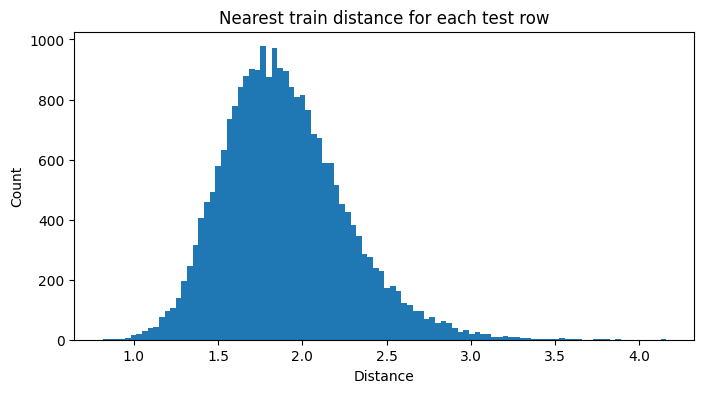

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(nearest_df["nearest_distance"], bins=100)
plt.title("Nearest train distance for each test row")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.show()

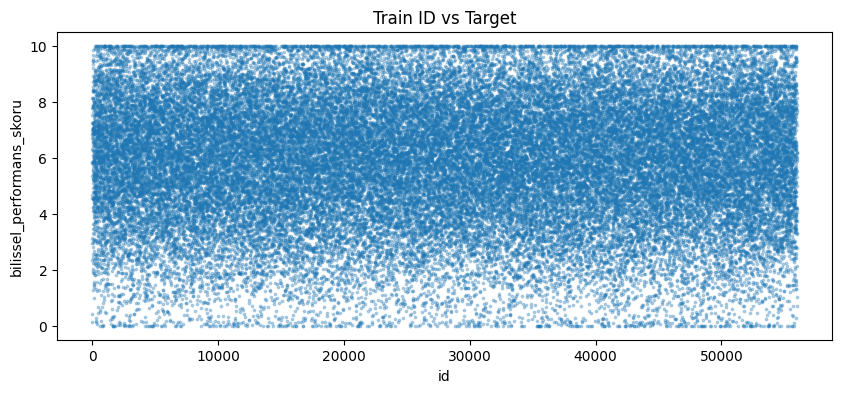

Correlation id-target:
                                 id  bilissel_performans_skoru
id                         1.000000                  -0.005845
bilissel_performans_skoru -0.005845                   1.000000


In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.scatter(train["id"], train[TARGET], s=3, alpha=0.3)
plt.title("Train ID vs Target")
plt.xlabel("id")
plt.ylabel(TARGET)
plt.show()

print("Correlation id-target:")
print(train[["id", TARGET]].corr())

,count,mean,std,min,max
id_bin,,,,,
"(0.999, 2800.95]",2800,6.000766,2.206065,0.0,10.0
"(2800.95, 5600.9]",2800,5.906122,2.199636,0.0,10.0
"(5600.9, 8400.85]",2800,5.910144,2.244792,0.0,10.0
"(8400.85, 11200.8]",2800,5.922100,2.225385,0.0,10.0
"(11200.8, 14000.75]",2800,5.900134,2.240593,0.0,10.0
"(14000.75, 16800.7]",2800,5.867705,2.204855,0.0,10.0
"(16800.7, 19600.65]",2800,5.932985,2.247683,0.0,10.0
"(19600.65, 22400.6]",2800,6.010627,2.233782,0.0,10.0
"(22400.6, 25200.55]",2800,5.933620,2.209602,0.0,10.0


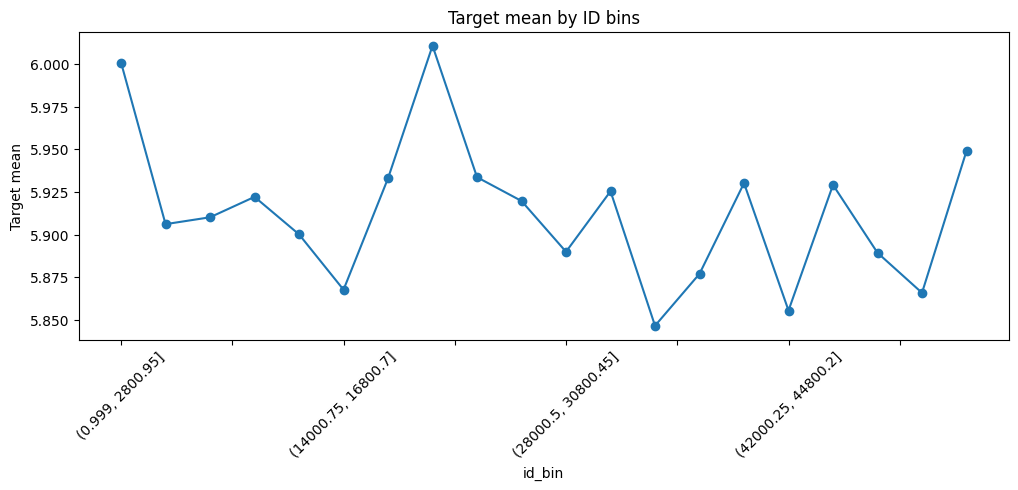

In [6]:
train_id_analysis = train[["id", TARGET]].copy()
train_id_analysis["id_bin"] = pd.qcut(train_id_analysis["id"], q=20, duplicates="drop")

id_bin_stats = train_id_analysis.groupby("id_bin")[TARGET].agg(["count", "mean", "std", "min", "max"])
display(id_bin_stats)

plt.figure(figsize=(12, 4))
id_bin_stats["mean"].plot(marker="o")
plt.title("Target mean by ID bins")
plt.ylabel("Target mean")
plt.xticks(rotation=45)
plt.show()

In [7]:
dist_rows = []

for col in numeric_cols:
    tr = train[col]
    te = test[col]

    dist_rows.append({
        "col": col,
        "train_mean": tr.mean(),
        "test_mean": te.mean(),
        "mean_diff": te.mean() - tr.mean(),
        "train_std": tr.std(),
        "test_std": te.std(),
        "std_diff": te.std() - tr.std(),
        "train_missing": tr.isna().mean(),
        "test_missing": te.isna().mean(),
        "missing_diff": te.isna().mean() - tr.isna().mean()
    })

dist_df = pd.DataFrame(dist_rows)
dist_df["abs_mean_diff_scaled"] = (dist_df["mean_diff"].abs() / (dist_df["train_std"] + 1e-9))

display(dist_df.sort_values("abs_mean_diff_scaled", ascending=False))
display(dist_df.sort_values("missing_diff", ascending=False))

,col,train_mean,test_mean,mean_diff,train_std,test_std,std_diff,train_missing,test_missing,missing_diff,abs_mean_diff_scaled
1,vucut_kitle_indeksi,26.273651,26.354491,0.080840,4.495138,4.455273,-0.039865,0.031286,0.027000,-0.004286,0.017984
2,rem_yuzdesi,20.233500,20.278214,0.044714,3.442993,3.424471,-0.018522,0.000000,0.000000,0.000000,0.012987
12,dinlenik_nabiz_bpm,66.603214,66.515250,-0.087964,7.353174,7.388835,0.035660,0.000000,0.000000,0.000000,0.011963
10,stres_skoru,5.741407,5.723828,-0.017579,1.624985,1.635602,0.010617,0.030625,0.031875,0.001250,0.010818
3,derin_uyku_yuzdesi,20.246063,20.292365,0.046302,4.300421,4.258140,-0.042280,0.000000,0.000000,0.000000,0.010767
11,gunluk_calisma_saati,7.156456,7.123312,-0.033144,3.469731,3.504064,0.034332,0.000000,0.000000,0.000000,0.009552
8,gunluk_adim_sayisi,7493.197554,7516.762917,23.565363,3462.699361,3462.578765,-0.120596,0.000000,0.000000,0.000000,0.006805
4,uykuya_dalma_suresi_dk,20.107536,20.063833,-0.043702,8.063278,8.050903,-0.012375,0.000000,0.000000,0.000000,0.005420
9,sekerleme_suresi_dk,15.432875,15.322667,-0.110208,21.104672,21.115702,0.011031,0.000000,0.000000,0.000000,0.005222
0,yas,34.714446,34.662125,-0.052321,11.052508,11.044303,-0.008205,0.000000,0.000000,0.000000,0.004734


,col,train_mean,test_mean,mean_diff,train_std,test_std,std_diff,train_missing,test_missing,missing_diff,abs_mean_diff_scaled
6,uyku_oncesi_kafein_mg,42.110952,42.361885,0.250933,72.154159,72.477832,0.323672,0.026125,0.029042,0.002917,0.003478
10,stres_skoru,5.741407,5.723828,-0.017579,1.624985,1.635602,0.010617,0.030625,0.031875,0.001250,0.010818
2,rem_yuzdesi,20.233500,20.278214,0.044714,3.442993,3.424471,-0.018522,0.000000,0.000000,0.000000,0.012987
4,uykuya_dalma_suresi_dk,20.107536,20.063833,-0.043702,8.063278,8.050903,-0.012375,0.000000,0.000000,0.000000,0.005420
3,derin_uyku_yuzdesi,20.246063,20.292365,0.046302,4.300421,4.258140,-0.042280,0.000000,0.000000,0.000000,0.010767
5,gecelik_uyanma_sayisi,3.344929,3.354333,0.009405,2.034618,2.027610,-0.007008,0.000000,0.000000,0.000000,0.004622
0,yas,34.714446,34.662125,-0.052321,11.052508,11.044303,-0.008205,0.000000,0.000000,0.000000,0.004734
11,gunluk_calisma_saati,7.156456,7.123312,-0.033144,3.469731,3.504064,0.034332,0.000000,0.000000,0.000000,0.009552
7,uyku_oncesi_ekran_suresi_dk,63.511446,63.516167,0.004720,44.590737,44.338866,-0.251871,0.000000,0.000000,0.000000,0.000106
8,gunluk_adim_sayisi,7493.197554,7516.762917,23.565363,3462.699361,3462.578765,-0.120596,0.000000,0.000000,0.000000,0.006805


# Target Mechanism / Formula Investigation

count    56000.000000
mean         5.913096
std          2.231759
min          0.000000
25%          4.397431
50%          6.032249
75%          7.574980
max         10.000000
Name: bilissel_performans_skoru, dtype: float64
Exact 0 count: 191
Exact 10 count: 789
Near 0 count (<0.1): 327
Near 10 count (>9.9): 1316


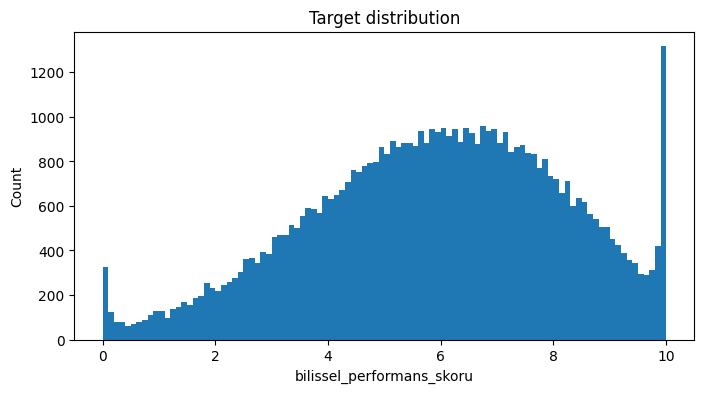

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET = "bilissel_performans_skoru"

print(train[TARGET].describe())

print("Exact 0 count:", (train[TARGET] == 0).sum())
print("Exact 10 count:", (train[TARGET] == 10).sum())
print("Near 0 count (<0.1):", (train[TARGET] < 0.1).sum())
print("Near 10 count (>9.9):", (train[TARGET] > 9.9).sum())

plt.figure(figsize=(8, 4))
plt.hist(train[TARGET], bins=100)
plt.title("Target distribution")
plt.xlabel(TARGET)
plt.ylabel("Count")
plt.show()

In [9]:
numeric_cols = train.drop(columns=["id", TARGET]).select_dtypes(include=np.number).columns.tolist()

corr_rows = []

for col in numeric_cols:
    corr_rows.append({
        "col": col,
        "corr": train[[col, TARGET]].corr().iloc[0, 1],
        "abs_corr": abs(train[[col, TARGET]].corr().iloc[0, 1])
    })

corr_df = pd.DataFrame(corr_rows).sort_values("abs_corr", ascending=False)
display(corr_df)

,col,corr,abs_corr
10,stres_skoru,-0.586676,0.586676
2,rem_yuzdesi,0.442999,0.442999
11,gunluk_calisma_saati,-0.342112,0.342112
3,derin_uyku_yuzdesi,0.280006,0.280006
5,gecelik_uyanma_sayisi,-0.270349,0.270349
4,uykuya_dalma_suresi_dk,-0.207349,0.207349
8,gunluk_adim_sayisi,0.134042,0.134042
12,dinlenik_nabiz_bpm,-0.089389,0.089389
0,yas,-0.070659,0.070659
6,uyku_oncesi_kafein_mg,-0.062387,0.062387


In [10]:
cat_cols = train.drop(columns=["id", TARGET]).select_dtypes(include="object").columns.tolist()

for col in cat_cols:
    print("=" * 80)
    print(col)
    stats = train.groupby(col, dropna=False)[TARGET].agg(["count", "mean", "std", "min", "max"])
    stats = stats.sort_values("mean", ascending=False)
    display(stats)

cinsiyet


/tmp/ipykernel_108366/1944674436.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.drop(columns=["id", TARGET]).select_dtypes(include="object").columns.tolist()


,count,mean,std,min,max
cinsiyet,,,,,
Erkek,27324,5.913804,2.224613,0.0,10.0
Kadin,28676,5.912420,2.238586,0.0,10.0


meslek


,count,mean,std,min,max
meslek,,,,,
Emekli,3778,7.935044,1.608945,0.946770,10.0
Ev Hanimi,3224,7.055969,1.802786,0.000000,10.0
Serbest Calisan,3812,6.985534,1.870769,0.010578,10.0
Egitimci,4395,6.343725,2.011186,0.000000,10.0
Muhendis,6533,6.223087,2.040621,0.000000,10.0
NaN,1378,6.022928,2.309071,0.000000,10.0
Satis ve Pazarlama Calisani,3899,6.010286,2.055236,0.000000,10.0
Yonetici,4454,5.729820,2.127878,0.000000,10.0
Ogrenci,8132,5.535248,2.111092,0.000000,10.0


...

,count,mean,std,min,max
ruh_sagligi_durumu,,,,,
Saglikli,38365,6.491822,2.018310,0.0,10.000000
NaN,1096,5.939361,2.184929,0.0,10.000000
Anksiyete,8270,5.012262,2.097732,0.0,10.000000
Depresyon,5504,4.394400,2.011677,0.0,9.674794
Anksiyete ve depresyon,2765,3.590186,2.046661,0.0,9.389999


mevsim


,count,mean,std,min,max
mevsim,,,,,
Sonbahar-Kis,27857,5.915958,2.225839,0.0,10.0
Ilkbahar-Yaz,28143,5.910262,2.237640,0.0,10.0


gun_tipi


,count,mean,std,min,max
gun_tipi,,,,,
Hafta sonu,15948,6.993307,1.938364,0.0,10.0
Hafta ici,40052,5.482975,2.195082,0.0,10.0


Missing columns: ['meslek', 'vucut_kitle_indeksi', 'uyku_oncesi_kafein_mg', 'stres_skoru', 'kronotip', 'ruh_sagligi_durumu']


,count,mean,std,min,max
missing_count,,,,,
0,47255,5.907238,2.231405,0.000000,10.000000
1,8135,5.938292,2.237339,0.000000,10.000000
2,593,6.038595,2.171165,0.000000,10.000000
3,17,5.759780,2.596194,0.460867,9.891059


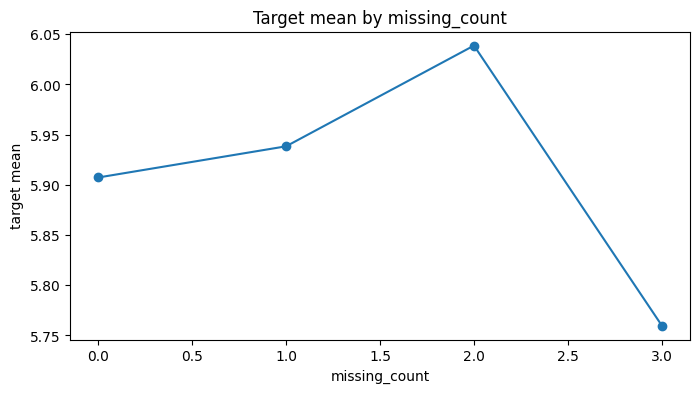

,col,missing_count,missing_rate,target_mean_missing,target_mean_not_missing,diff
0,meslek,1378,0.024607,6.022928,5.910325,0.112604
4,kronotip,1968,0.035143,6.016487,5.909330,0.107157
3,stres_skoru,1715,0.030625,5.958010,5.911677,0.046334
5,ruh_sagligi_durumu,1096,0.019571,5.939361,5.912571,0.026789
1,vucut_kitle_indeksi,1752,0.031286,5.910648,5.913175,-0.002526
2,uyku_oncesi_kafein_mg,1463,0.026125,5.837662,5.915119,-0.077457


In [11]:
feature_cols = [col for col in train.columns if col not in ["id", TARGET]]

missing_cols = [col for col in feature_cols if train[col].isna().any()]

print("Missing columns:", missing_cols)

train_missing = train.copy()
train_missing["missing_count"] = train_missing[feature_cols].isna().sum(axis=1)

missing_count_stats = train_missing.groupby("missing_count")[TARGET].agg(["count", "mean", "std", "min", "max"])
display(missing_count_stats)

plt.figure(figsize=(8, 4))
missing_count_stats["mean"].plot(marker="o")
plt.title("Target mean by missing_count")
plt.xlabel("missing_count")
plt.ylabel("target mean")
plt.show()

missing_effects = []

for col in missing_cols:
    mask = train[col].isna()
    missing_effects.append({
        "col": col,
        "missing_count": mask.sum(),
        "missing_rate": mask.mean(),
        "target_mean_missing": train.loc[mask, TARGET].mean(),
        "target_mean_not_missing": train.loc[~mask, TARGET].mean(),
        "diff": train.loc[mask, TARGET].mean() - train.loc[~mask, TARGET].mean()
    })

missing_effects_df = pd.DataFrame(missing_effects).sort_values("diff", ascending=False)
display(missing_effects_df)

In [12]:
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV, LinearRegression, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

X_formula = train.drop(columns=["id", TARGET])
y_formula = train[TARGET]

num_cols = X_formula.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_formula.select_dtypes(include="object").columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Bilinmiyor")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ]
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "RidgeCV": RidgeCV(alphas=np.logspace(-4, 4, 50)),
    "LinearRegression": LinearRegression(),
    "LassoCV": LassoCV(alphas=np.logspace(-4, 1, 30), max_iter=10000, random_state=42),
    "ElasticNetCV": ElasticNetCV(
        alphas=np.logspace(-4, 1, 20),
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        max_iter=10000,
        random_state=42
    )
}

formula_results = []

for model_name, model in models.items():
    print("=" * 80)
    print(model_name)

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    oof = np.zeros(len(X_formula))
    fold_scores = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X_formula), 1):
        X_tr = X_formula.iloc[tr_idx]
        X_va = X_formula.iloc[va_idx]
        y_tr = y_formula.iloc[tr_idx]
        y_va = y_formula.iloc[va_idx]

        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_va)
        pred = np.clip(pred, 0, 10)

        oof[va_idx] = pred

        score = rmse(y_va, pred)
        fold_scores.append(score)
        print(f"{model_name} Fold {fold} RMSE:", score)

    total_score = rmse(y_formula, oof)
    print(f"{model_name} OOF RMSE:", total_score)

    formula_results.append({
        "model": model_name,
        "oof_rmse": total_score,
        "fold_mean": np.mean(fold_scores),
        "fold_std": np.std(fold_scores)
    })

formula_results_df = pd.DataFrame(formula_results).sort_values("oof_rmse")
display(formula_results_df)

/tmp/ipykernel_108366/900453866.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_formula.select_dtypes(include="object").columns.tolist()


RidgeCV
RidgeCV Fold 1 RMSE: 1.256127730265553
RidgeCV Fold 2 RMSE: 1.2509165144605174
RidgeCV Fold 3 RMSE: 1.2376471867882113
RidgeCV Fold 4 RMSE: 1.2451290641479078
RidgeCV Fold 5 RMSE: 1.2724829424269286
RidgeCV OOF RMSE: 1.2525157711590102
LinearRegression
LinearRegression Fold 1 RMSE: 1.2561143098585719
LinearRegression Fold 2 RMSE: 1.2508887322637026
LinearRegression Fold 3 RMSE: 1.2376487365040334
LinearRegression Fold 4 RMSE: 1.2450817424506864
LinearRegression Fold 5 RMSE: 1.272483008255748
LinearRegression OOF RMSE: 1.2524984412436955
LassoCV
LassoCV Fold 1 RMSE: 1.2558881310289012
LassoCV Fold 2 RMSE: 1.2508928994830455
LassoCV Fold 3 RMSE: 1.2376882515371124
LassoCV Fold 4 RMSE: 1.2453015665516842
LassoCV Fold 5 RMSE: 1.2722160912884541
LassoCV OOF RMSE: 1.2524511987473772
ElasticNetCV
ElasticNetCV Fold 1 RMSE: 1.2559259856928164
ElasticNetCV Fold 2 RMSE: 1.2510001952371814
ElasticNetCV Fold 3 RMSE: 1.2376795501751907
ElasticNetCV Fold 4 RMSE: 1.245491212683251
ElasticNetCV

,model,oof_rmse,fold_mean,fold_std
2,LassoCV,1.252451,1.252397,0.011610
1,LinearRegression,1.252498,1.252443,0.011752
0,RidgeCV,1.252516,1.252461,0.011747
3,ElasticNetCV,1.252522,1.252468,0.011598


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV

top_num_cols = corr_df.head(8)["col"].tolist()
print("Top numeric columns:", top_num_cols)

X_poly = train[top_num_cols].copy()
y_poly = train[TARGET]

poly_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-4, 4, 50)))
])

poly_oof = np.zeros(len(X_poly))
poly_scores = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_poly), 1):
    X_tr = X_poly.iloc[tr_idx]
    X_va = X_poly.iloc[va_idx]
    y_tr = y_poly.iloc[tr_idx]
    y_va = y_poly.iloc[va_idx]

    poly_pipe.fit(X_tr, y_tr)
    pred = poly_pipe.predict(X_va)
    pred = np.clip(pred, 0, 10)

    poly_oof[va_idx] = pred

    score = rmse(y_va, pred)
    poly_scores.append(score)
    print(f"Polynomial Ridge Fold {fold} RMSE:", score)

print("Polynomial Ridge OOF RMSE:", rmse(y_poly, poly_oof))
print("Fold mean:", np.mean(poly_scores))

Top numeric columns: ['stres_skoru', 'rem_yuzdesi', 'gunluk_calisma_saati', 'derin_uyku_yuzdesi', 'gecelik_uyanma_sayisi', 'uykuya_dalma_suresi_dk', 'gunluk_adim_sayisi', 'dinlenik_nabiz_bpm']
Polynomial Ridge Fold 1 RMSE: 1.4940839006525501
Polynomial Ridge Fold 2 RMSE: 1.4776073288442317
Polynomial Ridge Fold 3 RMSE: 1.4757963491926513
Polynomial Ridge Fold 4 RMSE: 1.4828027022538388
Polynomial Ridge Fold 5 RMSE: 1.5092698989293905
Polynomial Ridge OOF RMSE: 1.4879640094007183
Fold mean: 1.4879120359745324


Using poly_oof
Residual summary:
count    56000.000000
mean         0.000835
std          1.487977
min         -6.594675
25%         -0.976944
50%          0.071648
75%          1.052553
max          6.205203
dtype: float64


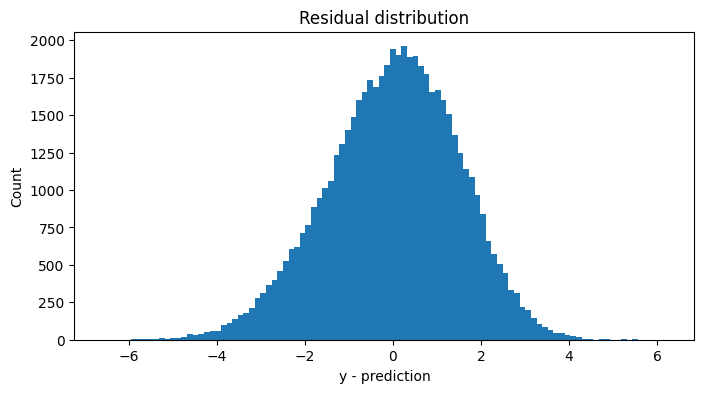


Numeric residual correlations:


/tmp/ipykernel_108366/2737386440.py:35: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_res = feature_df.select_dtypes(include="object").columns.tolist()


,col,residual_corr,abs_residual_corr
9,sekerleme_suresi_dk,-0.066587,0.066587
6,uyku_oncesi_kafein_mg,-0.040883,0.040883
0,yas,0.038549,0.038549
13,oda_sicakligi_celsius,-0.017658,0.017658
7,uyku_oncesi_ekran_suresi_dk,-0.010829,0.010829
1,vucut_kitle_indeksi,0.006926,0.006926
14,hafta_sonu_uyku_farki_saat,-0.004927,0.004927
10,stres_skoru,-0.002231,0.002231
2,rem_yuzdesi,0.002064,0.002064
11,gunluk_calisma_saati,-0.001284,0.001284


cinsiyet


,count,mean,std,abs_mean
cinsiyet,,,,
Kadin,28676,0.005266,1.484671,0.005266
Erkek,27324,-0.003815,1.491451,0.003815


...

mevsim


,count,mean,std,abs_mean
mevsim,,,,
Sonbahar-Kis,27857,0.002698,1.484601,0.002698
Ilkbahar-Yaz,28143,-0.001008,1.491335,0.001008


gun_tipi


,count,mean,std,abs_mean
gun_tipi,,,,
Hafta sonu,15948,0.639704,1.385446,0.639704
Hafta ici,40052,-0.253551,1.450586,0.253551


: 

In [ ]:
# ============================================================
# Residual analysis using ridge_oof fallback
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET = "bilissel_performans_skoru"

if "ridge_oof" in globals():
    base_oof = ridge_oof
    print("Using ridge_oof from formula-search model")
elif "poly_oof" in globals():
    base_oof = poly_oof
    print("Using poly_oof")
else:
    raise ValueError("ridge_oof veya poly_oof yok. Önce formula-search hücresini çalıştır.")

residual = train[TARGET].values - np.asarray(base_oof)

print("Residual summary:")
print(pd.Series(residual).describe())

plt.figure(figsize=(8, 4))
plt.hist(residual, bins=100)
plt.title("Residual distribution")
plt.xlabel("y - prediction")
plt.ylabel("Count")
plt.show()

feature_df = train.drop(columns=["id", TARGET])

numeric_cols_res = feature_df.select_dtypes(include=np.number).columns.tolist()
cat_cols_res = feature_df.select_dtypes(include="object").columns.tolist()

residual_corrs = []

for col in numeric_cols_res:
    values = train[col].fillna(train[col].median()).values
    corr = np.corrcoef(values, residual)[0, 1]

    residual_corrs.append({
        "col": col,
        "residual_corr": corr,
        "abs_residual_corr": abs(corr)
    })

residual_corr_df = pd.DataFrame(residual_corrs).sort_values(
    "abs_residual_corr",
    ascending=False
)

print("\nNumeric residual correlations:")
display(residual_corr_df.head(20))

for col in cat_cols_res:
    print("=" * 80)
    print(col)

    temp = train[[col]].copy()
    temp["residual"] = residual
    temp[col] = temp[col].fillna("Bilinmiyor").astype(str)

    stats = temp.groupby(col)["residual"].agg(["count", "mean", "std"])
    stats["abs_mean"] = stats["mean"].abs()
    stats = stats.sort_values("abs_mean", ascending=False)

    display(stats.head(20))